In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy.io import loadmat
from plot_CTD import *
import os
import gsw
%matplotlib inline
%load_ext autoreload
%autoreload 2
# define the paths and filenames
import os, sys
sys.path.append(os.getcwd())
os.chdir("../../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")
ds2 = xr.open_dataset(path + "Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2.nc", engine="netcdf4")
ds3 = xr.open_dataset(path + "Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast3.nc", engine="netcdf4")
ds = xr.concat([ds2, ds3], dim="time")

In [2]:
time_casts = [pd.to_datetime('2021-11-02 02:57:55', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 03:15:55', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 03:45:40', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 03:45:20', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 04:00:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 04:20:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 00:26:55', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 00:45:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:12:20', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:12:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:23:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:39:00', format='%Y-%m-%d %H:%M:%S')]

In [3]:
lat = -77.8667
lon = 166.23333333333332

SA = xr.DataArray(
    gsw.SA_from_SP(
        ds.SP,
        ds.Pressure_dbar,
        lon,
        lat,
    ),
    dims=["time"],
    coords={"time": ds.time},
)

ds["SA"] = SA


In [4]:
CT = xr.DataArray(
    gsw.CT_from_t(
        ds.SA,
        ds.Temperature,      # ITS-90 (this is correct for gsw)
        ds.Pressure_dbar,
    ),
    dims=["time"],
    coords={"time": ds.time},
)

ds["CT"] = CT

In [5]:
fp = xr.DataArray(
    gsw.CT_freezing(
        ds.SA,
        ds.Pressure_dbar,
        0.0,   # saturation_fraction; 0 = no air
    ),
    dims=["time"],
    coords={"time": ds.time},
)

ds["fp"] = fp

In [6]:
SC = xr.DataArray(
    abs(CT) - abs(fp),
    dims=["time"],
    coords={"time": ds.time},
)

ds["SC"] = SC

In [7]:
sigma0 = xr.DataArray(
    gsw.sigma0(
        ds.SA,
        ds.CT,
    ),
    dims=["time"],
    coords={"time": ds.time},
)

ds["sigma0"] = sigma0

In [8]:
depth = xr.DataArray(
    gsw.z_from_p(
        ds.Pressure_dbar,
        lat,
    ),
    dims=["time"],
    coords={"time": ds.time},
)

ds.coords["depth"] = -depth  # convert z (negative downward) to depth (positive)

In [11]:
t_potential = gsw.pt_from_t(ds.SA, ds.Temperature, ds.Pressure_dbar, p_ref=0)

sc_potential = xr.DataArray(np.abs(t_potential)-np.abs(fp),
    dims=["time"],
    coords={"time": ds.time},
)

ds["SC_potential"] = sc_potential

In [12]:
# evaluate errors
from error_analysis import*

# Example nominal values:
C_Sm = ds.con.data       # conductivity [S/m] (roughly expected at the measurement site;
                # TO-DO: find value from upper ~40 m CTD / mixed; Fig. 7a)
T90_C   = ds.Temperature.data      # in-situ temperature [°C, ITS-90] (from upper ~40 m CTD / mixed; Fig. 7a)

# evaluate the pressure for the instrument depth
# camp 2021 coordinates
lon = 166.23333333333332
lat = -77.86666666666666

# Instrument 1-sigma uncertainties:
delta_t = 4 # months; calibration date CT 30 June 2021
uC_Sm = 0.0003 + delta_t * 0.0003     # S/m (SBE 19plus data sheet)
uT_C = 0.005 + delta_t * 0.0002   # deg C (SBE 19plus data sheet)
uP_dbar = 0.1*1e-2*ds.Pressure_dbar + 0.02*1e-2*ds.Pressure_dbar + (1/12) * 0.02*1e-2*ds.Pressure_dbar * delta_t  # (SBE19plus data sheet)

# if not os.path.exists(path + "Ant2021/Ant2021CTDdata/SBE19plus_cast2_3_errors_teos10.nc"):
#     res = propagate_uncertainty_teos10(
#         C_Sm, ds.CT, ds.Pressure_dbar,
#         uC_Sm, uT_C, uP_dbar, lon=lon, lat=lat,
#         n_samples=3000, seed=123
#     )
#     res.to_netcdf(path + "Ant2021/Ant2021CTDdata/SBE19plus_cast2_3_errors_teos10.nc", engine="netcdf4")
# else:
#     res = xr.open_dataset(path + "Ant2021/Ant2021CTDdata/SBE19plus_cast2_3_errors_teos10.nc", engine="netcdf4")


/home/nina/CODE/mcmurdo-2021-frazil-ice-currents-supercooling/CTD_2021/error_analysis.py:7: UserWarning: The seawater library is deprecated! Please use gsw instead.
  from seawater import fp, pden


In [13]:
from error_analysis import*
res_tot = total_uncertainty_TEOS10(
    ds.SA, ds.CT, ds.Pressure_dbar, uP_dbar,
    C_Sm, uC_Sm,
    uT_C,
    lon, lat
)

In [14]:
res_tot

{'uTf': <xarray.DataArray (time: 35196)> Size: 282kB
 array([1.02185441e-05, 1.02185441e-05, 1.02185441e-05, ...,
                   nan,            nan,            nan], shape=(35196,))
 Coordinates:
   * time     (time) datetime64[ns] 282kB 2021-11-02T02:57:55 ... 2021-11-03T0...
     depth    (time) float64 282kB 0.0009895 0.0009895 ... 0.06828 0.06828,
 'urho': <xarray.DataArray (time: 35196)> Size: 282kB
 array([0.01643165, 0.01643165, 0.01643165, ...,        nan,        nan,
               nan], shape=(35196,))
 Coordinates:
   * time     (time) datetime64[ns] 282kB 2021-11-02T02:57:55 ... 2021-11-03T0...
     depth    (time) float64 282kB 0.0009895 0.0009895 ... 0.06828 0.06828,
 'ruSA': np.float64(0.0006022394646298032)}

/home/nina/DATA/CTD_all_up_teos10.png


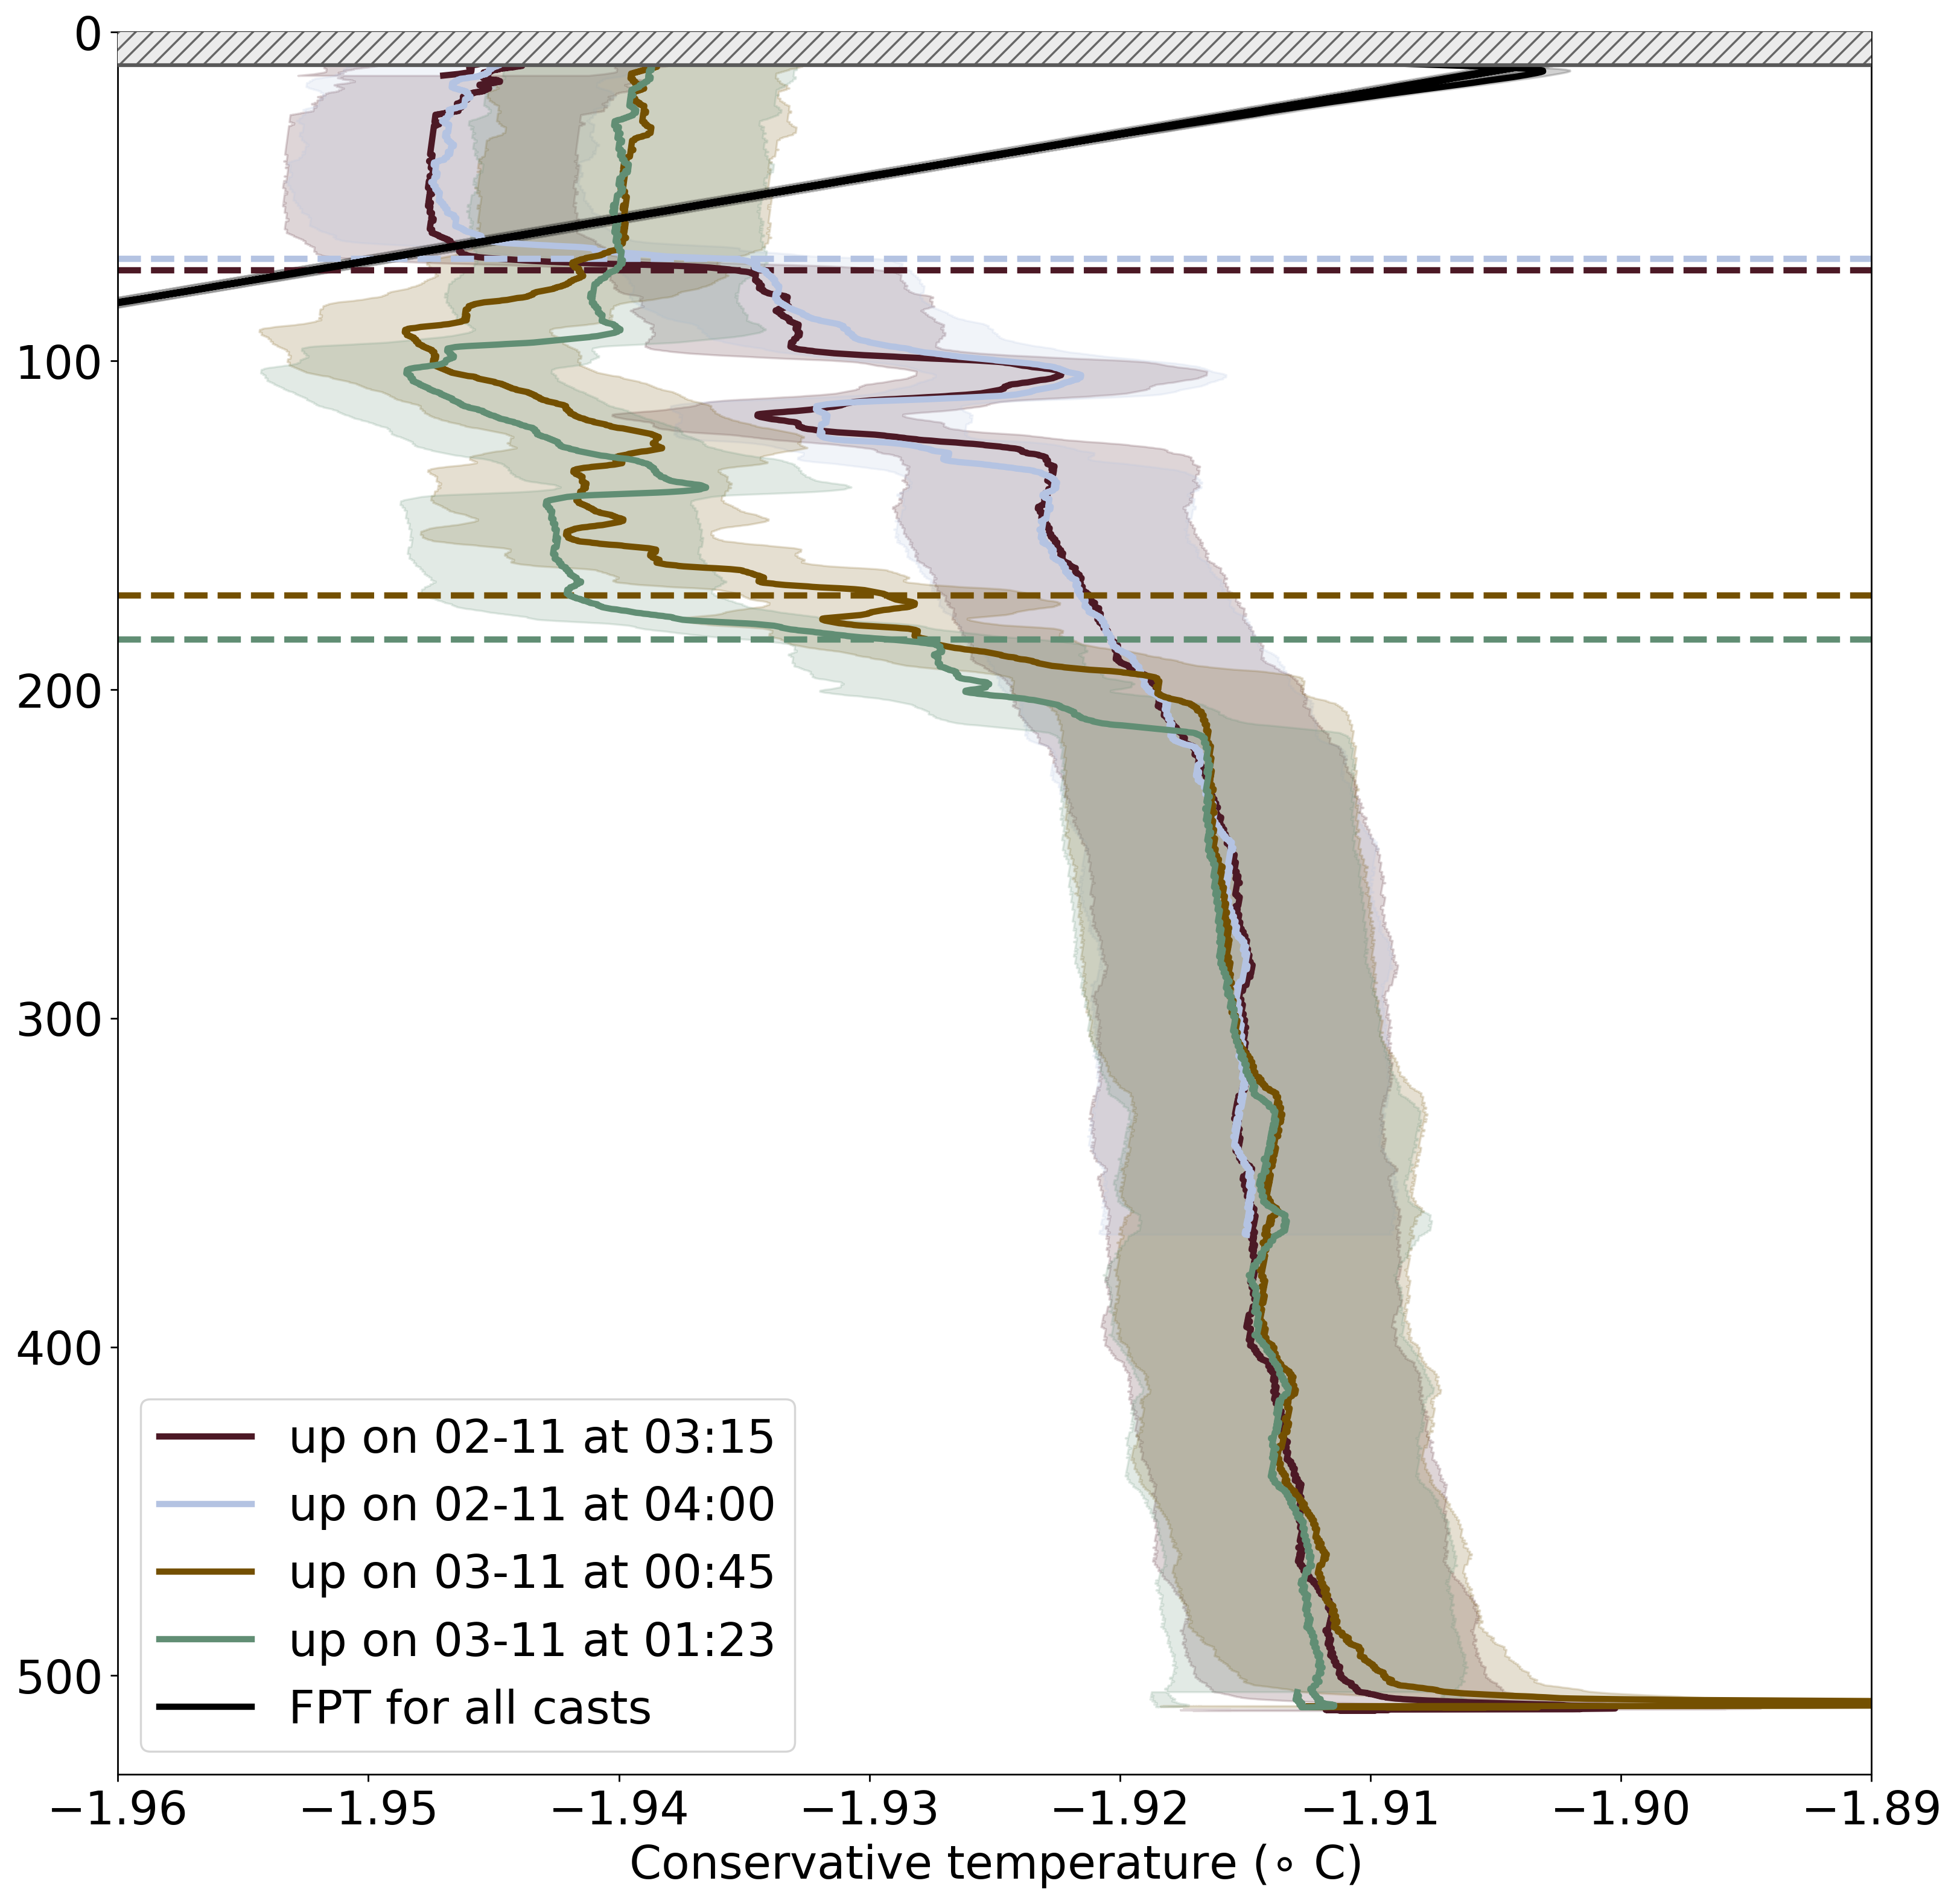

In [16]:
import cmcrameri.cm as cmr

# pick a colour‑blind–friendly map with good contrast on white
cmap = cmr.glasgow   # other solid choices: cmr.batlow, cmr.oslo, cmr.lapaz

cast_indices = list(range(len(time_casts)))[0:-8]
N = len(cast_indices)

# sample N colours from the central range to avoid very light/dark extremes
base_colors = cmap(np.linspace(0.1, 0.92, N))

# (optional) reorder colours to maximize separation between adjacent casts
left, right = 0, N - 1
order = []
while left <= right:
    order.append(left)
    if left != right:
        order.append(right)
    left += 1
    right -= 1
colors = base_colors[order]

fig, ax = plt.subplots(figsize=(15, 15), dpi=250)
ds = ds.assign_coords(depth=("time", ds["depth"].values))
for k, i in enumerate(cast_indices):
    # select upcast
    mid_time = time_casts[i*3 + 1]
    end_time = time_casts[i*3 + 2]
    up_start = mid_time
    up_end = end_time
    time_up = up_start
    up_cast = ds.sel(time=slice(up_start, up_end))
    # Make depth indexable
    # 1) Sort by depth (so the new axis is ordered)
    ds_sorted = up_cast.sortby('depth')
    # 2) Ensure all depths are unique (otherwise swap_dims will fail)
    # Round depths to avoid float jitter from EOS-80 vs TEOS-10
    depth_rounded = np.round(ds_sorted['depth'].values, 3)
    # Get first index of each unique depth (in the sorted depth order)
    _, unique_idx = np.unique(depth_rounded, return_index=True)
    ds_unique = ds_sorted.isel(time=np.sort(unique_idx))
    # 3) Swap the dimension: time -> depth
    ds_depth = ds_unique.swap_dims({'time': 'depth'})
    # discard upper 10m
    ds_below10 = ds_depth.sel(depth=slice(10, None))
    # select depth range
    ds0 = ds_below10.sel(depth=slice(10,20))
    # calculate surface layer temperature
    T0 = ds0.CT.mean().data
    # calculate deltaT
    deltaT = abs(ds_below10.CT - T0)
    # find deltaT>0.015
    idx = np.argmax(deltaT.data > 0.01)
    # fig, ax = plot_up(ds, uT_C, res, fig, ax, mid_time, end_time, color=colors[k])
    ax.plot(
    up_cast.CT,
    up_cast.depth, 
    label="up on " + time_up.strftime("%d-%m") + " at " + time_up.strftime("%H:%M"),
    color = colors[k],
    linewidth=3
)
    ax.fill_betweenx(up_cast.depth, up_cast.CT - uT_C, up_cast.CT + uT_C, alpha=0.18, color=colors[k])
    ax.axhline(ds_below10.depth[idx], color=colors[k], linestyle = "--", linewidth=3)

# opaque 0–10 m mask
ax.set_xlim([-1.96, -1.89])
ax.axhspan(0, 10, facecolor="0.92", edgecolor="0.4",
            hatch="///", linewidth=0.0, alpha=1.0, zorder=5)
ax.axhline(y=10, color="0.35", linewidth=1.8, zorder=6)
ax.set_ylim([530, 0])

ax.plot(ds.fp, ds.depth, label="FPT for all casts", color="k", linewidth=3)
ax.fill_betweenx(ds.depth, ds.fp - res_tot["uTf"], ds.fp + res_tot["uTf"], alpha=0.18, color="k")
ax.set_xlabel(r"Conservative temperature ($\circ$ C)")
ax.legend()
plt.rcParams["font.size"] = 22
plt.savefig(savedir+"/CTD_all_up_teos10.png",
            bbox_inches="tight")
print(savedir+"/CTD_all_up_teos10.png")

(34.75, 34.95)

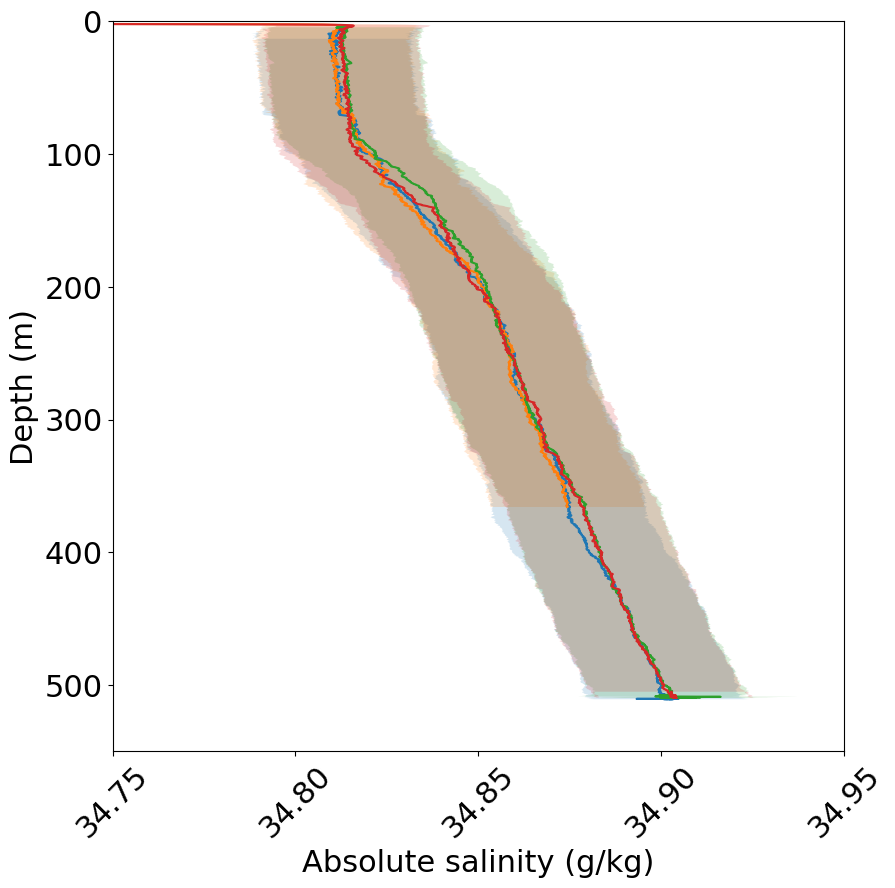

In [17]:
# plot salinity
ru_SA = res_tot["ruSA"]
fig, ax = plt.subplots(1,1, figsize=(9,9))

for i in range(len(time_casts))[0:-8]:
    mid_time = time_casts[i*3+1]
    end_time = time_casts[i*3+2]
    
    up_start = mid_time
    up_end = end_time
    time_up = up_start
    
    up_cast = ds.sel(time=slice(up_start, up_end))
    # u_SA = res.sel(time=slice(up_start, up_end)).u_SA.data
    
    ax.plot(
        up_cast.SA,
        up_cast.depth, 
        label="up on " + time_up.strftime("%d-%m") + " at " + time_up.strftime("%H:%M")
    )
    ax.fill_betweenx(up_cast.depth, up_cast.SA - ru_SA*up_cast.SA, up_cast.SA + ru_SA*up_cast.SA, alpha=0.18)
    ax.set_ylim([0, 550])
    ax.set_xlabel("Absolute salinity (g/kg)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelrotation=45)
    # ax.legend(loc="upper right")
    #    ax2.legend()
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.tight_layout()
plt.rcParams["font.size"] = 22
ax.set_xlim([34.75, 34.95])

(27.875, 28.0)

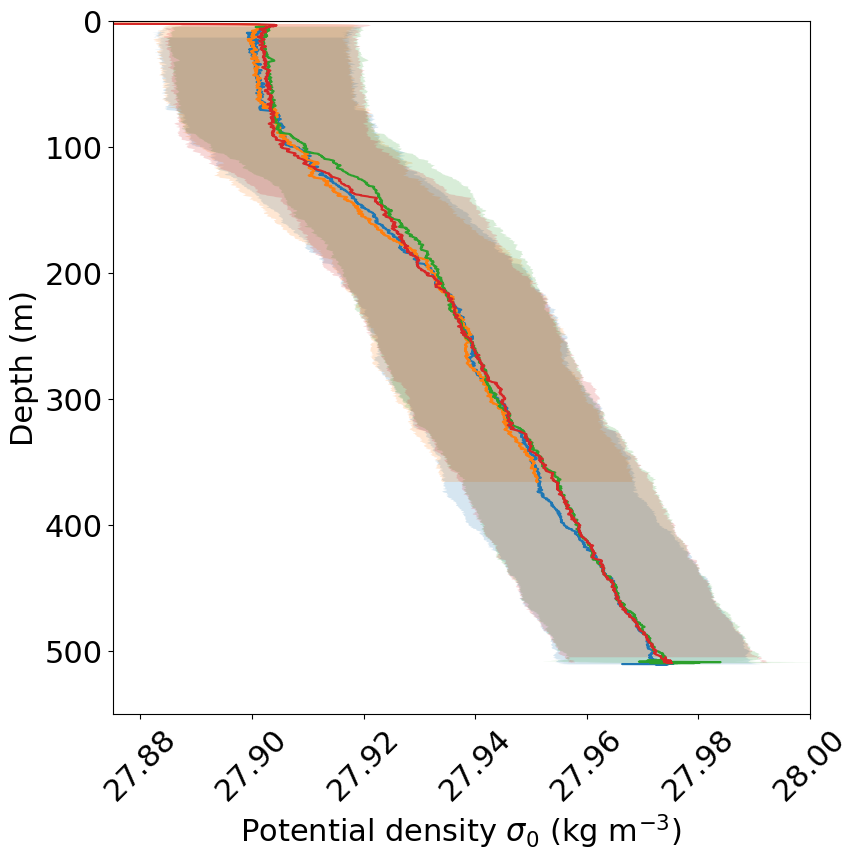

In [18]:
# plot potential density with absolute uncertainty

u_rho = res_tot["urho"]  # absolute uncertainty (kg m^-3, depth-dependent)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

for i in range(len(time_casts))[0:-8]:
    mid_time = time_casts[i*3+1]
    end_time = time_casts[i*3+2]

    up_start = mid_time
    up_end   = end_time
    time_up  = up_start

    up_cast = ds.sel(time=slice(up_start, up_end))

    ax.plot(
        up_cast.sigma0,          # or up_cast.rho if that's what you stored
        up_cast.depth,
        label="up on " + time_up.strftime("%d-%m") + " at " + time_up.strftime("%H:%M")
    )

    # absolute uncertainty band
    ax.fill_betweenx(
        up_cast.depth,
        up_cast.sigma0 - u_rho,
        up_cast.sigma0 + u_rho,
        alpha=0.18
    )

ax.set_ylim([0, 550])
ax.invert_yaxis()
ax.set_xlabel(r"Potential density $\sigma_0$ (kg m$^{-3}$)")
ax.set_ylabel("Depth (m)")
ax.tick_params(axis="x", labelrotation=45)

# optional limits – adjust if needed
ax.set_xlim([27.875, 28])

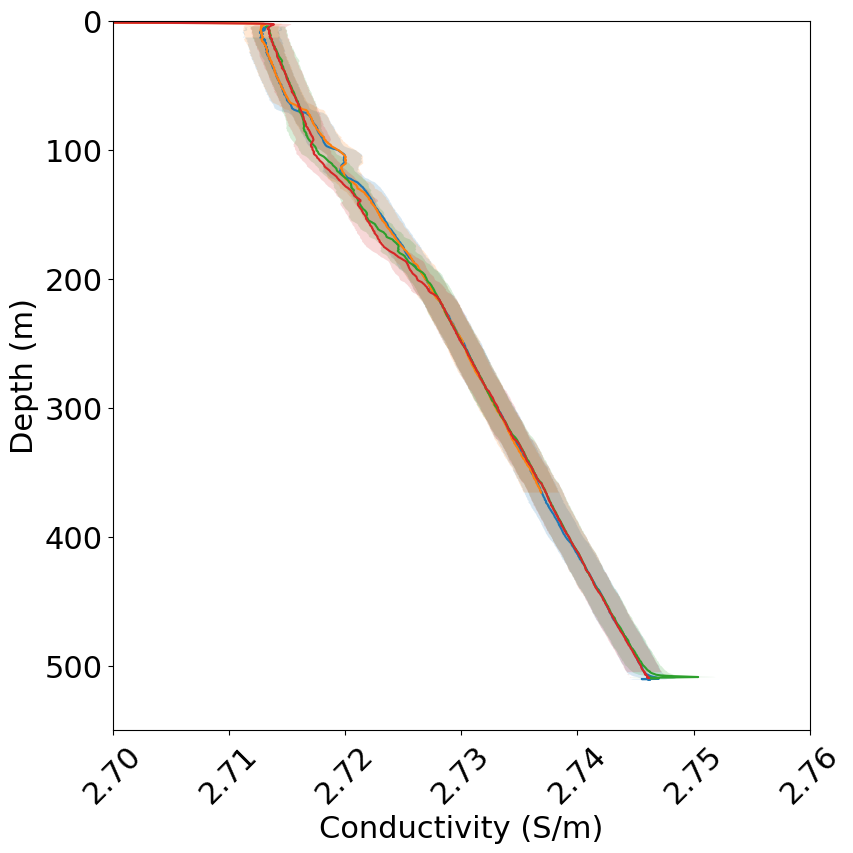

In [19]:
# plot conductivity
fig, ax = plt.subplots(1,1, figsize=(9,9))

for i in range(len(time_casts))[0:-8]:
    mid_time = time_casts[i*3+1]
    end_time = time_casts[i*3+2]
    
    up_start = mid_time
    up_end = end_time
    time_up = up_start
    
    up_cast = ds.sel(time=slice(up_start, up_end))
    
    ax.plot(
        up_cast.con,
        up_cast.depth, 
        label="up on " + time_up.strftime("%d-%m") + " at " + time_up.strftime("%H:%M")
    )
    ax.fill_betweenx(up_cast.depth, up_cast.con - uC_Sm, up_cast.con + uC_Sm, alpha=0.18)
    ax.set_xlim([2.7, 2.76])
    ax.set_ylim([0, 550])
    ax.set_xlabel("Conductivity (S/m)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelrotation=45)
    # ax.legend(loc="upper right")
    #    ax2.legend()
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.tight_layout()
    plt.rcParams["font.size"] = 22

In [20]:
if os.path.exists(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC_teos10.nc"):
    os.remove(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC_teos10.nc")
ds.to_netcdf(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC_teos10.nc", engine="netcdf4")